## Loading data

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("CitiesExt.csv")
df

,city,country,population,EU,coastline,latitude,longitude,temperature
0,Aalborg,Denmark,5.69,yes,yes,57.03,9.92,7.52
1,Aberdeen,United Kingdom,65.11,yes,yes,57.17,-2.08,8.10
2,Abisko,Sweden,9.85,yes,yes,63.35,18.83,0.20
3,Adana,Turkey,79.62,no,yes,36.99,35.32,18.67
4,Albacete,Spain,46.06,yes,yes,39.00,-1.87,12.62
...,...,...,...,...,...,...,...,...
208,Yevpatoriya,Ukraine,44.62,no,yes,45.20,33.36,10.02
209,Zaragoza,Spain,46.06,yes,yes,41.65,-0.89,14.17
210,Zhytomyr,Ukraine,44.62,no,yes,50.25,28.66,6.67
211,Zonguldak,Turkey,79.62,no,yes,41.43,31.78,10.64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         213 non-null    object 
 1   country      213 non-null    object 
 2   population   213 non-null    float64
 3   EU           213 non-null    object 
 4   coastline    213 non-null    object 
 5   latitude     213 non-null    float64
 6   longitude    213 non-null    float64
 7   temperature  213 non-null    float64
dtypes: float64(4), object(4)
memory usage: 13.4+ KB


In [4]:
df.describe()

,population,latitude,longitude,temperature
count,213.000000,213.000000,213.000000,213.000000
mean,40.090845,47.499906,15.374319,9.497840
std,28.727819,6.730961,13.068014,3.561231
min,0.070000,36.130000,-9.140000,-2.200000
25%,9.480000,42.220000,5.380000,7.190000
50%,44.620000,47.580000,16.180000,8.880000
75%,64.670000,52.050000,25.620000,11.190000
max,80.680000,67.850000,41.930000,18.670000


## Visualization

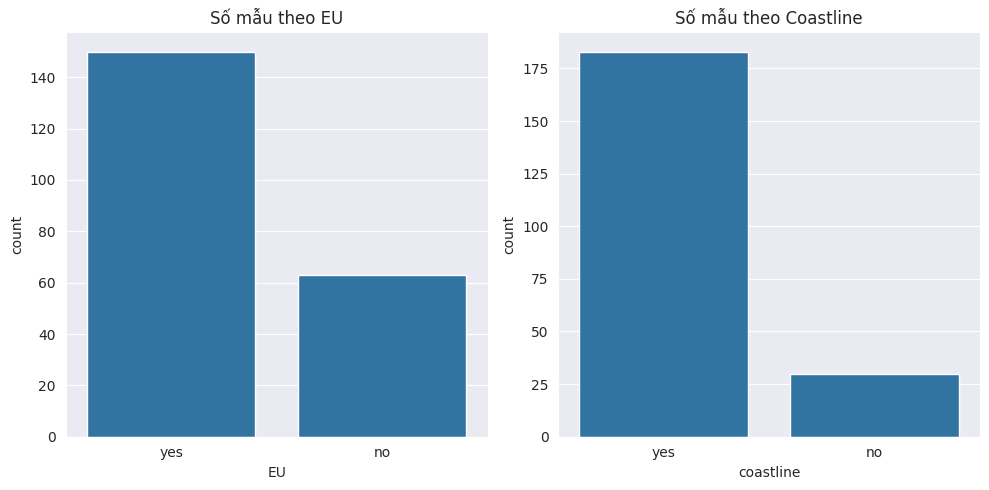

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Đếm số mẫu gia nhập EU
sns.countplot(data=df, x='EU', ax=axes[0])
axes[0].set_title("Số mẫu theo EU")

# Đếm số mẫu có Coastline
sns.countplot(data=df, x='coastline', ax=axes[1])
axes[1].set_title("Số mẫu theo Coastline")

plt.tight_layout()
plt.show()

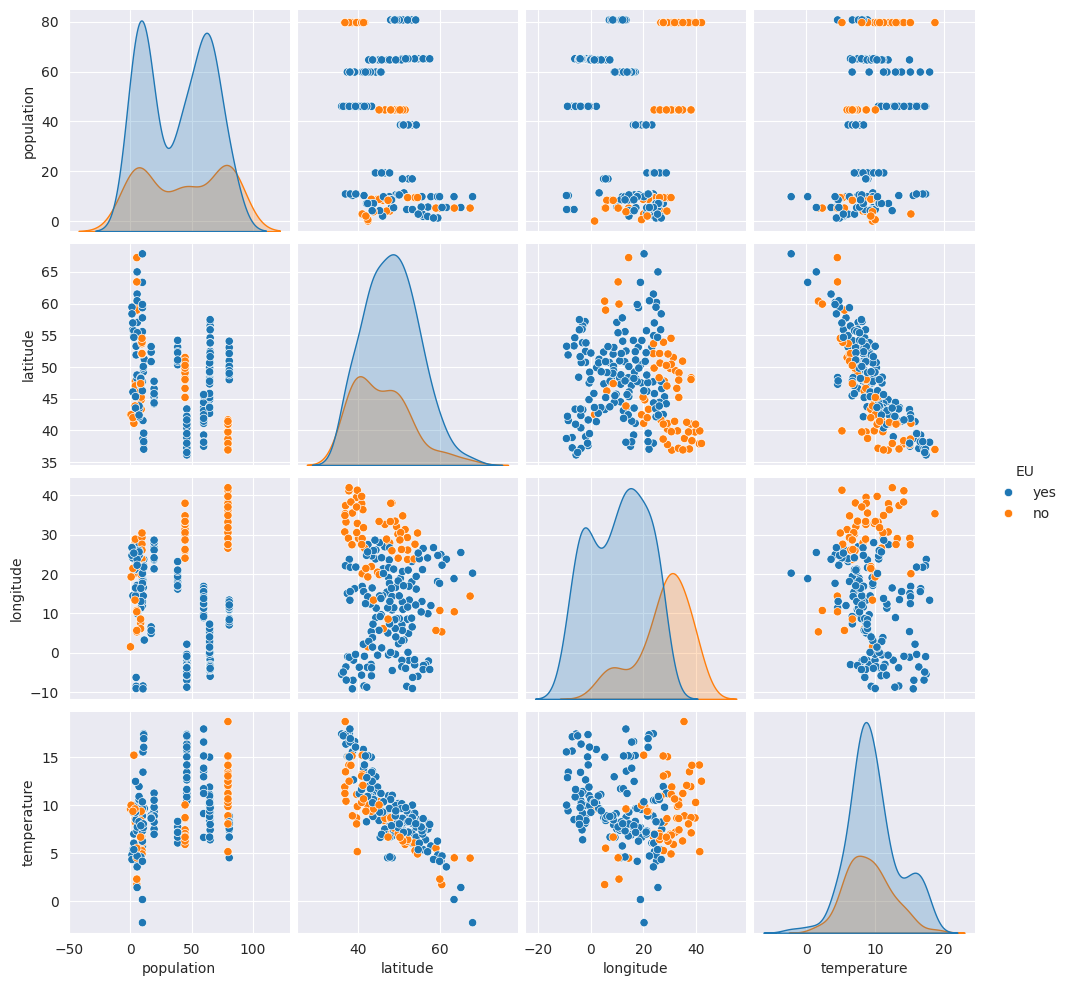

In [7]:
variable = ['population', 'latitude', 'longitude', 'temperature']

sns.pairplot(data=df,
             vars=variable,
             hue='EU',
             diag_kind='kde') #đường cong mật độ trên đường chéo

* Có thể thấy rõ mối quan hệ nghịch biến của latitude với temperature
* Các nước EU có dân số phân bố khá lệch, còn các nước ko thuộc EU thì phân bố đều hơn
* Các nước không thuộc EU hầu như có dân số khá lớn
* Dễ dàng thấy các nước thuộc và không thuộc EU phân tách rõ ràng qua latitude và longitude

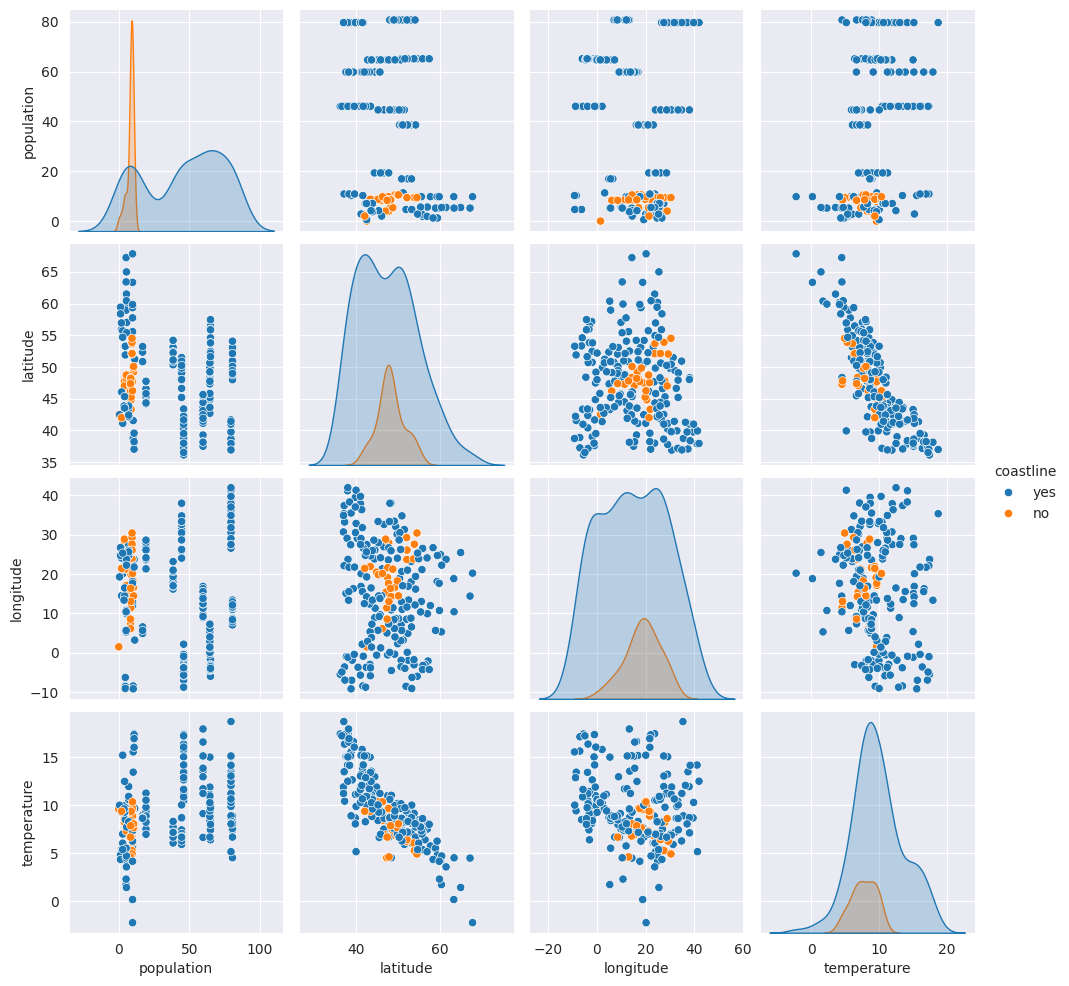

In [11]:
sns.pairplot(data=df,
             vars=variable,
             hue='coastline',
             diag_kind='kde')

* Các nước có bờ biển chiếm phần lớn, dân số phân bố đều, các nước không có bờ biển có số dân tương đồng, và ít
* Các nước không có bờ biển tập trung thành 1 cụm

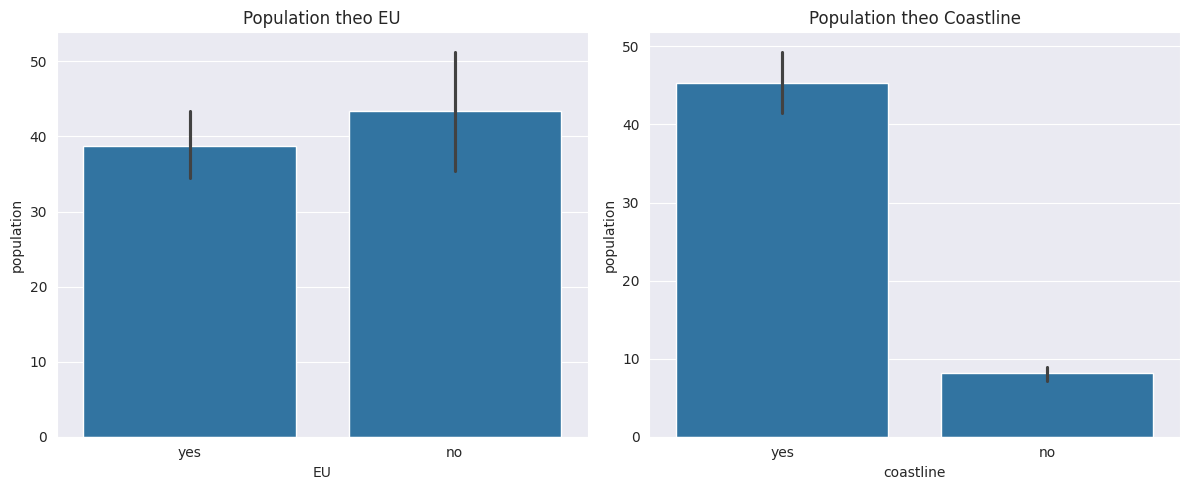

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 hàng, 2 cột

# Population theo EU
sns.barplot(
    data=df,
    x='EU',
    y='population',
    ax=axes[0]
)
axes[0].set_title("Population theo EU")

# Population theo Coastline
sns.barplot(
    data=df,
    x='coastline',
    y='population',
    ax=axes[1]
)
axes[1].set_title("Population theo Coastline")

plt.tight_layout()
plt.show()


<Axes: >

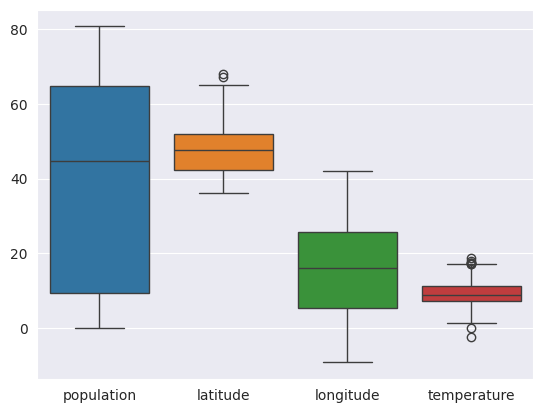

In [18]:
sns.boxplot(data=df)

<Axes: >

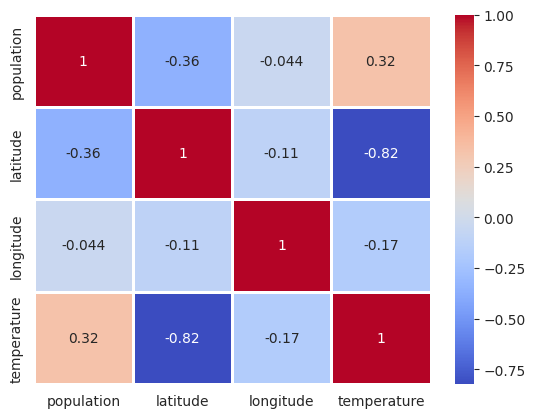

In [20]:
sns.heatmap(df[variable].corr(), annot=True, cmap='coolwarm', linewidths=2)